## [Part 1]  NextStore: A data-driven system to predict the growth of Internet celebrity shop

**Background**

The Internet celebrity shop is a popular trend in every city all over the world. There are always some successful
ones, while some shops struggle to survive. You need to find out what are the factors affecting the success of
the shops, so that the owners can make more reasonable decisions.
For this assignment, we will focus on [Boston Italian Restaurants](https://www.yelp.com/search?find_desc=Italian&find_loc=Boston%2C+MA%2C+United+States) and collect at least 20 data from Yelp. The data
that we will collect will be the number of dollar $, number of violations in health score feature, good for groups,
good for kids, pet/dog allowed, the number of reviews to predict the number of star ratings (note you can
choose different data points, just make sure you have at least 6)

### Task 1: data collection

Collect 20 data points from Yelp. Use the provided google form template

\* Note: 0 = No, 1 = Yes

### Task 2: preprocessing

Create a dataframe from the table you collected, separate the features and labels. You can apply any data preprocessing techniques if necessary, split the train and test sets (test_size = 1/5).

In [2]:
import pandas as pd
import numpy as np

In [14]:
# TODO: establish a DataFrame from the form you collected
# Data from the user input
data = {
    'Dollars': [3, 2, 2, 2, 2, 2, 3, 2, 3, 4, 4, 4, 1, 1, 1, 1, 3, 3, 3, 2],
    'Offers Delivery': [0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1],
    'Good for group': [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1],
    'Good for kids': [1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1],
    'Pet/dog allowed': [0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    'Number of reviews': [3696, 4223, 379, 269, 602, 349, 2540, 2246, 2286, 540, 1127, 1273, 789, 1242, 175, 908, 1665, 6328, 1474, 1076],
    'Star rating': [4.5, 4.2, 2.8, 3.7, 4.2, 3.5, 4.2, 3.8, 4.1, 3.6, 4.4, 4, 4.4, 3.9, 1.4, 4.2, 3.6, 4.3, 4.1, 3.9]
}

# Create DataFrame
df = pd.DataFrame(data)
df

,Dollars,Offers Delivery,Good for group,Good for kids,Pet/dog allowed,Number of reviews,Star rating
0,3,0,0,1,0,3696,4.5
1,2,1,0,1,0,4223,4.2
2,2,0,1,1,0,379,2.8
3,2,1,1,1,0,269,3.7
4,2,1,1,0,1,602,4.2
5,2,0,1,1,1,349,3.5
6,3,1,1,0,1,2540,4.2
7,2,1,1,1,1,2246,3.8
8,3,1,1,1,1,2286,4.1
9,4,1,1,1,0,540,3.6


In [15]:
# TODO: separate the features (X) and labels (y)
# Separate features and labels
X = df.drop(columns=['Star rating'])
y = df['Star rating']

In [ ]:
# TODO: preprocessing if necessary


In [22]:
# TODO: train-test split

from sklearn.model_selection import train_test_split
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Task 3: regression

You need to first figure out which type of regression model can be used in this case. Then declare the corresponding regressor object, and fit your model with X_train and y_train.

In [24]:
# TODO: import the regressor from sklearn, declare the regressor object, and fit your model

# Import the regressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
# Function to evaluate models
def evaluate_model(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mse, r2, y_pred

# Linear Regression
linear_regressor = LinearRegression()
linear_mse, linear_r2, linear_pred = evaluate_model(linear_regressor)

# Decision Tree Regression
tree_regressor = DecisionTreeRegressor(random_state=42)
tree_mse, tree_r2, tree_pred = evaluate_model(tree_regressor)

# Random Forest Regression
forest_regressor = RandomForestRegressor(random_state=42)
forest_mse, forest_r2, forest_pred = evaluate_model(forest_regressor)


### Task 4: predictions

Make predictions on the test set based on your model (you can try out multiple regressors and pick the one that gives the best reuslt).

In [33]:
# TODO: ^
# Compare the results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree Regression', 'Random Forest Regression'],
    'MSE': [linear_mse, tree_mse, forest_mse],
    'R^2 Score': [linear_r2, tree_r2, forest_r2]
})

print(results)

# Display predictions of the best model (assuming Random Forest is the best for now)
best_pred = forest_pred
comparison_df = pd.DataFrame({"Actual": y_test.values, "Predicted": best_pred})
print(comparison_df)

                      Model       MSE   R^2 Score
0         Linear Regression  5.622807 -373.853824
1  Decision Tree Regression  6.487500 -431.500000
2  Random Forest Regression  0.731910  -47.793967
   Actual  Predicted
0     4.5      3.363
1     4.3      3.363
2     4.2      4.098
3     4.2      3.336


### Task 5: visualization

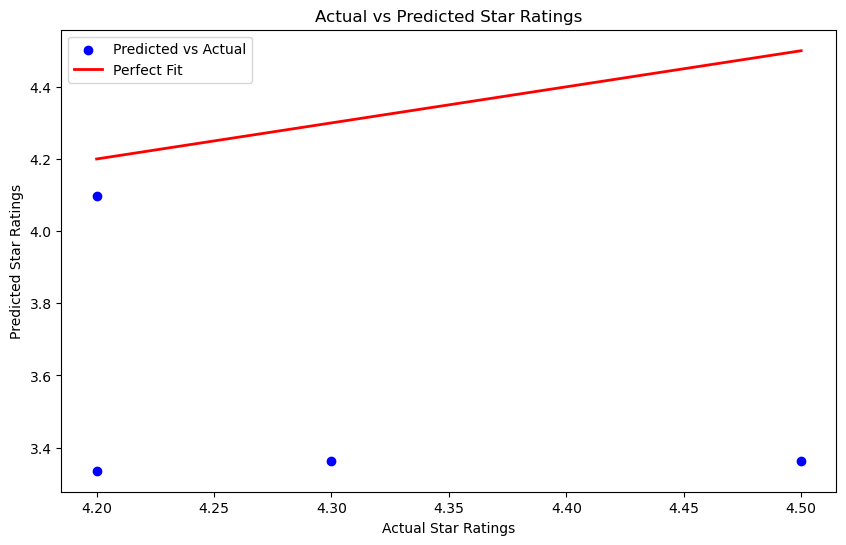

In [34]:
# TODO: plot y_test and y_pred to visualize the performance of your model
import matplotlib.pyplot as plt

# Assuming Random Forest was the best model based on previous evaluation
best_pred = forest_pred

# Create a scatter plot to visualize actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, best_pred, color='blue', label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2, label='Perfect Fit')
plt.xlabel('Actual Star Ratings')
plt.ylabel('Predicted Star Ratings')
plt.title('Actual vs Predicted Star Ratings')
plt.legend()
plt.show()

## [Part 2]  SVM for classifying spam emails

In the provided data, the text emails have been pre-processed to ensure that only the email body and subject remain in the dataset; email addresses (EMAILADDR), web addresses (HTTPADDR), currency (DOLLAR) and numbers (NUMBER) were also replaced by the special tokens (features) to allow them to be considered properly in the classification process.

We have done the feature extraction works for you, so you can just load the data matrices (called document-term matrices in text classification) which contain all the data. In a document-term matrix, the ith row represents the ith email, and the jth column represents the jth distinct token. Thus, the (i, j) entry of this matrix represents the number of occurrences of the jth token in the ith document.

For this problem, we chose the set of tokens (vocabulary) to only contain the medium frequency tokens, as the tokens that occur too often or too rarely do not have much classification value. Also, terms were stemmed using a standard stemming algorithm; basically, this means that “price,” “prices” and “priced” have all been replaced with “price,” so that they can be treated as the same token.

In [1]:
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC

In [3]:
# helper functions
def readMatrix(filename: str):
  with open(filename, 'r') as fd:
      hdr = fd.readline()
      rows, cols = [int(s) for s in fd.readline().strip().split()]
      tokens = fd.readline().strip().split()
      matrix = np.zeros((rows, cols))
      Y = []
      for i, line in enumerate(fd):
          nums = [int(x) for x in line.strip().split()]
          Y.append(nums[0])
          kv = np.array(nums[1:])
          k = np.cumsum(kv[:-1:2])
          v = kv[1::2]
          matrix[i, k] = v
      return matrix, tokens, np.array(Y)


def evaluate(output, label) -> float:
  # Use the code below to obtain the accuracy of your algorithm
  error = float((output != label).sum()) * 1. / len(output)
  print('Error: {:2.4f}%'.format(100 * error))
  return error

### Task 1: simple implementation

Repeat the first task, but with training sets of size ranging from 50, 100, 200, ..., up to 1400 by using the files MATRIX.TRAIN.*. Plot the test error vs. training set size in a curve. Also, report the numer of support vectors for each of the learned models and include this curve in the same plot.

In [8]:
# TODO: read train and test matrices to np arrays
train_matrix, tokens, train_labels = readMatrix('MATRIX.TRAIN')
test_matrix, tokens, test_labels = readMatrix('MATRIX.TEST')

In [9]:
# TODO: fit classifier
# Initialize the LinearSVC classifier
classifier = LinearSVC()

# Fit the classifier on the training data
classifier.fit(train_matrix, train_labels)

# TODO: test and evluate
# Predict the labels for the test data
predicted_labels = classifier.predict(test_matrix)

# Evaluate the classifier
error = evaluate(predicted_labels, test_labels)
print(f'Accuracy: {100 * (1 - error):.4f}%')

Error: 0.3750%
Accuracy: 99.6250%


/Users/mac/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/mac/anaconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### Task 2: explore different training set sizes and visualization

Repeat the first task, but with training sets of size ranging from 50, 100, 200, ..., up to 1400 by using the files MATRIX.TRAIN.*. Plot the test error vs. training set size in a curve. Also, report the numer of support vectors for rach of the learned models.

In [10]:
# TODO: train the support vector classifier with datasets of difference sizes (see different files enclosed in the homework folder),
#       get the test errors and report the number of support vectors for each case.
# Load test matrix
test_matrix, tokens, test_labels = readMatrix('MATRIX.TEST')

# Define the training set sizes
training_sizes = [50, 100, 200, 400, 800, 1400]

# Initialize lists to store results
test_errors = []
support_vectors = []

# Loop through each training size
for size in training_sizes:
    # Load the training matrix for the current size
    train_matrix, _, train_labels = readMatrix(f'MATRIX.TRAIN.{size}')
    
    # Train the SVM classifier
    clf = LinearSVC()
    clf.fit(train_matrix, train_labels)
    
    # Predict on the test set
    test_predictions = clf.predict(test_matrix)
    
    # Evaluate the model
    error = evaluate(test_predictions, test_labels)
    test_errors.append(error)
    
    # Store the number of support vectors
    support_vectors.append(len(clf.coef_))

Error: 5.0000%
Error: 3.0000%
Error: 1.2500%
Error: 1.0000%
Error: 1.0000%
Error: 0.8750%


/Users/mac/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/mac/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/mac/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/mac/anaconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/mac/anaconda3/lib/python3

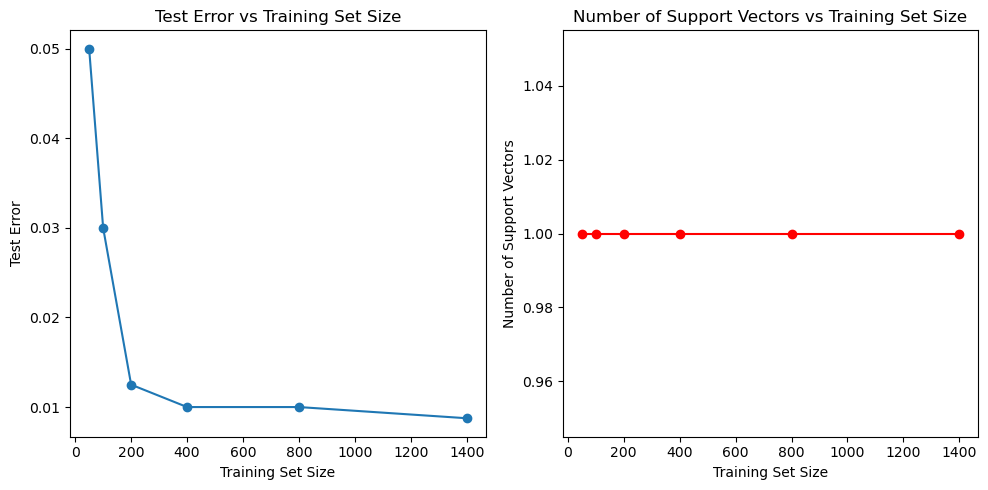

In [11]:
# TODO: plot the test error vs. training set size and # support vectors vs. training set size
# Plot test error vs training set size
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(training_sizes, test_errors, marker='o')
plt.title('Test Error vs Training Set Size')
plt.xlabel('Training Set Size')
plt.ylabel('Test Error')

# Plot number of support vectors vs training set size
plt.subplot(1, 2, 2)
plt.plot(training_sizes, support_vectors, marker='o', color='r')
plt.title('Number of Support Vectors vs Training Set Size')
plt.xlabel('Training Set Size')
plt.ylabel('Number of Support Vectors')

plt.tight_layout()
plt.show()